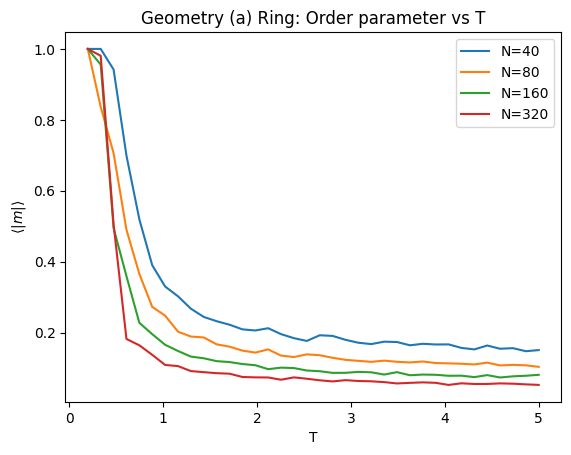

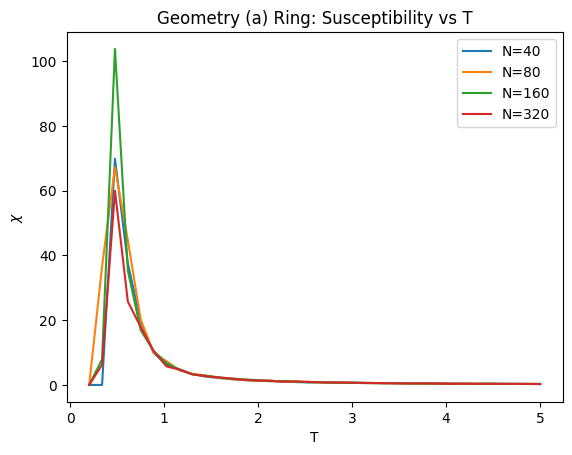

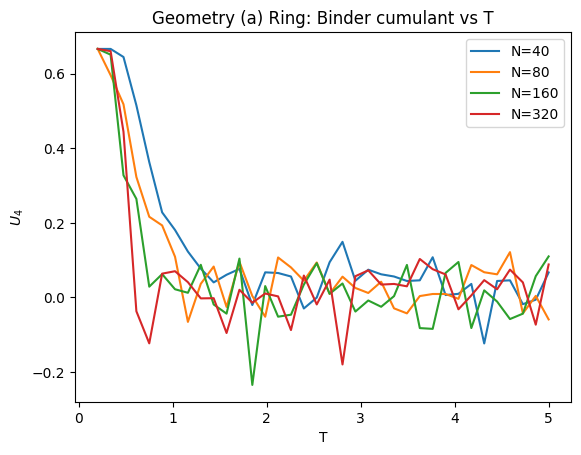

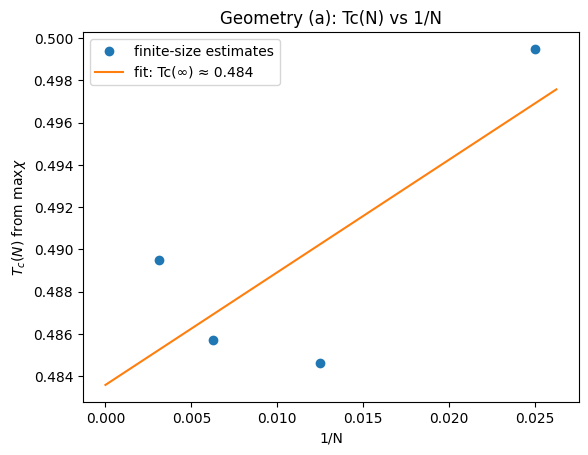

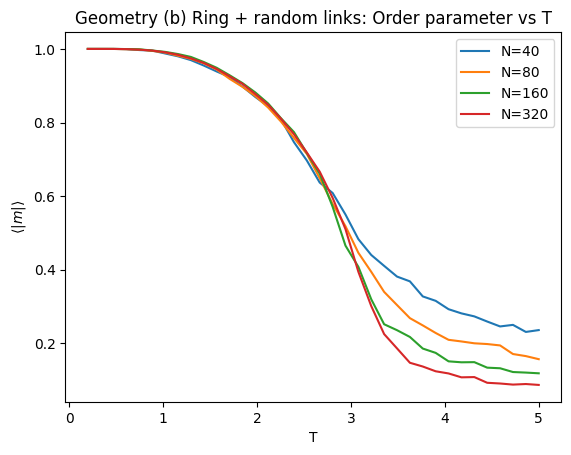

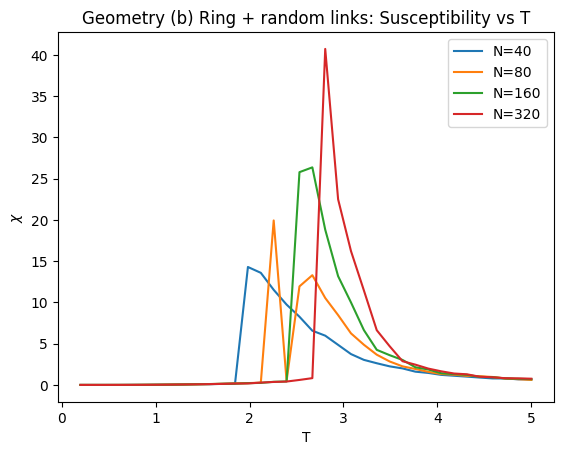

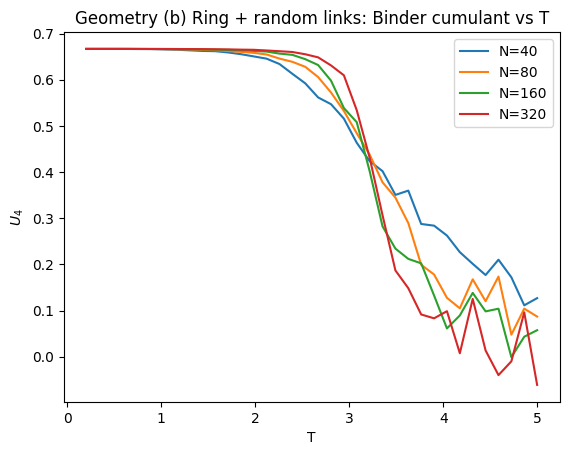

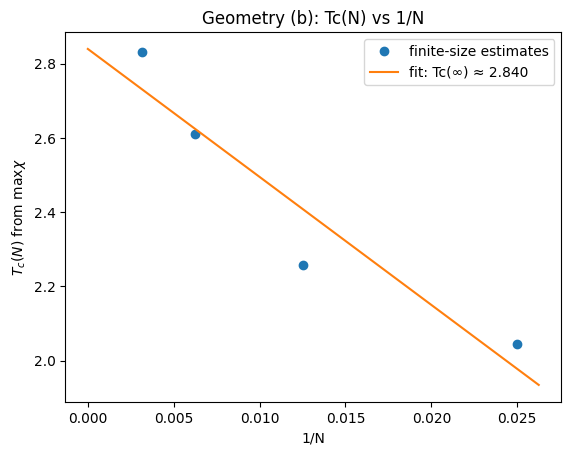

[A] Estimated Tc(∞) ~ 0.484 (should tend to 0 in 1D).
[B] Estimated Tc(∞) ~ 2.840 (finite, > 0, mean-field-like).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

# =========================
# Utilities / geometry
# =========================

def ring_neighbors(N: int) -> List[np.ndarray]:
    """
    Geometry (a): 1D periodic ring.
    Each node i has neighbors (i-1) % N and (i+1) % N.
    """
    nbrs = []
    for i in range(N):
        nbrs.append(np.array([(i - 1) % N, (i + 1) % N], dtype=int))
    return nbrs


def ring_plus_random_neighbors(
    N: int,
    extra_edges: int,
    rng: np.random.Generator,
) -> List[np.ndarray]:
    """
    Geometry (b): Start from ring and add 'extra_edges' *undirected* random edges.
    - The ring already has N undirected edges.
    - If we want on average +2 neighbors per node, we must add N undirected edges.
      (Because each undirected edge contributes +2 to the sum of degrees.)
    - Edges are kept fixed during the simulation.

    Constraints:
      - Simple graph: no self-loops, no duplicate edges.
      - Undirected: if (i, j) is present, then so is (j, i).

    Returns adjacency as list of np.ndarray neighbors for each node.
    """
    # Start with ring adjacency (sets for easy add/check)
    adj = [set([ (i - 1) % N, (i + 1) % N ]) for i in range(N)]

    # Edge set to prevent duplicates; store with ordered tuple (min, max)
    edges = set()
    for i in range(N):
        a, b = i, (i + 1) % N
        if a > b:
            a, b = b, a
        edges.add((a, b))

    # Add extra random undirected edges
    added = 0
    target = extra_edges
    while added < target:
        i = int(rng.integers(0, N))
        j = int(rng.integers(0, N))
        if i == j:
            continue
        a, b = (i, j) if i < j else (j, i)
        if (a, b) in edges:
            continue
        # add
        edges.add((a, b))
        adj[i].add(j)
        adj[j].add(i)
        added += 1

    # Convert back to arrays
    return [np.array(sorted(list(s)), dtype=int) for s in adj]


# =========================
# Ising model / Metropolis
# =========================

@dataclass
class IsingConfig:
    N: int
    J: float = 1.0
    seed: Optional[int] = 0
    geometry: str = "A"  # "A" = ring; "B" = ring + random links
    # For geometry B only:
    extra_edges: int = None  # If None, default to N (i.e., +2 avg neighbors)

class IsingSystem:
    def __init__(self, cfg: IsingConfig):
        self.cfg = cfg
        self.N = cfg.N
        self.J = cfg.J
        self.rng = np.random.default_rng(cfg.seed)

        if cfg.geometry.upper() == "A":
            self.neighbors = ring_neighbors(self.N)
        elif cfg.geometry.upper() == "B":
            # By default, add N undirected edges → +2 neighbors on average
            extra_edges = self.N if cfg.extra_edges is None else cfg.extra_edges
            self.neighbors = ring_plus_random_neighbors(self.N, extra_edges, self.rng)
        else:
            raise ValueError("Unknown geometry: use 'A' or 'B'.")

        # Random initial spins {-1, +1}
        self.spins = self.rng.choice([-1, 1], size=self.N).astype(np.int8)

    def energy_per_spin(self) -> float:
        # H = -J * sum_{<ij>} s_i s_j; we compute via site-sum /2 to avoid double-count
        E = 0.0
        for i in range(self.N):
            E -= self.J * self.spins[i] * np.sum(self.spins[self.neighbors[i]])
        return E / (2.0 * self.N)

    def magnetization(self) -> float:
        return np.mean(self.spins)

    def delta_E_flip(self, i: int) -> float:
        # dE if flipping spin at site i
        s_i = self.spins[i]
        nb_sum = np.sum(self.spins[self.neighbors[i]])
        return 2.0 * self.J * s_i * nb_sum

    def metropolis_sweep(self, beta: float):
        # N attempted single-spin updates
        for _ in range(self.N):
            i = int(self.rng.integers(0, self.N))
            dE = self.delta_E_flip(i)
            if dE <= 0.0:
                self.spins[i] *= -1
            else:
                if self.rng.random() < np.exp(-beta * dE):
                    self.spins[i] *= -1

    def run_at_T(
        self,
        T: float,
        burnin_sweeps: int = 2_000,
        meas_sweeps: int = 10_000,
        sample_every: int = 10,
    ) -> Dict[str, float]:
        beta = 1.0 / T
        # Burn-in
        for _ in range(burnin_sweeps):
            self.metropolis_sweep(beta)

        # Measurements
        m_list = []
        e_list = []
        for sw in range(meas_sweeps):
            self.metropolis_sweep(beta)
            if (sw % sample_every) == 0:
                m = self.magnetization()
                e = self.energy_per_spin()
                m_list.append(m)
                e_list.append(e)

        m_arr = np.array(m_list)
        e_arr = np.array(e_list)

        # Observables (k_B = 1)
        m_abs = np.mean(np.abs(m_arr))
        m2 = np.mean(m_arr**2)
        m4 = np.mean(m_arr**4)
        m_mean = np.mean(m_arr)

        chi = self.N * (m2 - m_mean**2) / T  # susceptibility
        binder = 1.0 - m4 / (3.0 * (m2**2) + 1e-15)  # Binder cumulant U4

        return {
            "T": T,
            "m_abs": m_abs,
            "m_mean": m_mean,
            "chi": chi,
            "binder": binder,
            "e": np.mean(e_arr),
        }


# =========================
# Scans & analysis helpers
# =========================

def scan_temperatures(
    cfg: IsingConfig,
    T_list: np.ndarray,
    burnin_sweeps: int = 2_000,
    meas_sweeps: int = 10_000,
    sample_every: int = 10,
) -> Dict[str, np.ndarray]:
    sys = IsingSystem(cfg)
    rec = {"T": [], "m_abs": [], "m_mean": [], "chi": [], "binder": [], "e": []}
    for T in T_list:
        obs = sys.run_at_T(
            T, burnin_sweeps=burnin_sweeps, meas_sweeps=meas_sweeps, sample_every=sample_every
        )
        for k in rec:
            rec[k].append(obs[k])
    return {k: np.array(v) for k, v in rec.items()}


def estimate_Tc_from_chi_peak(T: np.ndarray, chi: np.ndarray) -> float:
    """
    Find T at which chi is maximal, then do a tiny quadratic interpolation
    around the max (if interior) for a sub-grid estimate.
    """
    idx = int(np.argmax(chi))
    # Interior? try fit a parabola through (idx-1, idx, idx+1)
    if 1 <= idx <= len(T) - 2:
        x = T[idx - 1 : idx + 2]
        y = chi[idx - 1 : idx + 2]
        # Fit y = ax^2 + bx + c
        A = np.vstack([x**2, x, np.ones_like(x)]).T
        a, b, c = np.linalg.lstsq(A, y, rcond=None)[0]
        if a < 0:  # parabola opens downward → maximum at -b/(2a)
            return -b / (2.0 * a)
    # Fallback: grid maximum
    return float(T[idx])


def finite_size_extrapolation(invN: np.ndarray, TcN: np.ndarray) -> Tuple[float, float]:
    """
    Fit Tc(N) = Tc_inf + a*(1/N) by linear regression.
    Returns (Tc_inf, a).
    """
    A = np.vstack([np.ones_like(invN), invN]).T
    Tc_inf, a = np.linalg.lstsq(A, TcN, rcond=None)[0]
    return Tc_inf, a


# =========================
# Plotting
# =========================

def plot_many(
    results_per_N: Dict[int, Dict[str, np.ndarray]],
    title_prefix: str,
    show: bool = True,
    save_prefix: Optional[str] = None,
):
    # m_abs
    plt.figure()
    for N, rec in sorted(results_per_N.items()):
        plt.plot(rec["T"], rec["m_abs"], label=f"N={N}")
    plt.xlabel("T")
    plt.ylabel(r"$\langle |m| \rangle$")
    plt.title(f"{title_prefix}: Order parameter vs T")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_mabs.png", dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    # Susceptibility
    plt.figure()
    for N, rec in sorted(results_per_N.items()):
        plt.plot(rec["T"], rec["chi"], label=f"N={N}")
    plt.xlabel("T")
    plt.ylabel(r"$\chi$")
    plt.title(f"{title_prefix}: Susceptibility vs T")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_chi.png", dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    # Binder
    plt.figure()
    for N, rec in sorted(results_per_N.items()):
        plt.plot(rec["T"], rec["binder"], label=f"N={N}")
    plt.xlabel("T")
    plt.ylabel(r"$U_4$")
    plt.title(f"{title_prefix}: Binder cumulant vs T")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_binder.png", dpi=150, bbox_inches="tight")
    if show:
        plt.show()


def plot_Tc_extrapolation(invN: np.ndarray, TcN: np.ndarray, title: str, save: Optional[str] = None):
    Tc_inf, a = finite_size_extrapolation(invN, TcN)
    x = np.linspace(0, invN.max() * 1.05, 200)
    y = Tc_inf + a * x

    plt.figure()
    plt.plot(invN, TcN, "o", label="finite-size estimates")
    plt.plot(x, y, "-", label=f"fit: Tc(∞) ≈ {Tc_inf:.3f}")
    plt.xlabel("1/N")
    plt.ylabel(r"$T_c(N)$ from $\max \chi$")
    plt.title(title)
    plt.legend()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


# =========================
# Demo / main
# =========================

if __name__ == "__main__":
    # Temperatures to scan (adjust as you like)
    T_list = np.linspace(0.2, 5.0, 36)

    # System sizes to compare
    Ns = [40, 80, 160, 320]

    # MC parameters (tweak for accuracy vs runtime)
    burnin = 1500
    meas = 6000
    sample_every = 10

    # ---------- Geometry (a): 1D ring ----------
    results_A: Dict[int, Dict[str, np.ndarray]] = {}
    Tc_peaks_A = []
    invN_A = []

    for N in Ns:
        cfgA = IsingConfig(N=N, J=1.0, seed=123, geometry="A")
        recA = scan_temperatures(cfgA, T_list, burnin, meas, sample_every)
        results_A[N] = recA
        TcN = estimate_Tc_from_chi_peak(recA["T"], recA["chi"])
        Tc_peaks_A.append(TcN)
        invN_A.append(1.0 / N)

    plot_many(results_A, title_prefix="Geometry (a) Ring", save_prefix="geomA")

    Tc_peaks_A = np.array(Tc_peaks_A)
    invN_A = np.array(invN_A)
    plot_Tc_extrapolation(invN_A, Tc_peaks_A, title="Geometry (a): Tc(N) vs 1/N", save="geomA_Tc_extrap.png")

    # ---------- Geometry (b): ring + random extra links ----------
    # Add exactly N extra undirected edges → +2 neighbors on average (degree ~ 4)
    results_B: Dict[int, Dict[str, np.ndarray]] = {}
    Tc_peaks_B = []
    invN_B = []

    for N in Ns:
        cfgB = IsingConfig(N=N, J=1.0, seed=999, geometry="B", extra_edges=N)
        recB = scan_temperatures(cfgB, T_list, burnin, meas, sample_every)
        results_B[N] = recB
        TcN = estimate_Tc_from_chi_peak(recB["T"], recB["chi"])
        Tc_peaks_B.append(TcN)
        invN_B.append(1.0 / N)

    plot_many(results_B, title_prefix="Geometry (b) Ring + random links", save_prefix="geomB")

    Tc_peaks_B = np.array(Tc_peaks_B)
    invN_B = np.array(invN_B)
    plot_Tc_extrapolation(invN_B, Tc_peaks_B, title="Geometry (b): Tc(N) vs 1/N", save="geomB_Tc_extrap.png")

    # Print quick summaries
    Tc_inf_A, _ = finite_size_extrapolation(invN_A, Tc_peaks_A)
    Tc_inf_B, _ = finite_size_extrapolation(invN_B, Tc_peaks_B)
    print(f"[A] Estimated Tc(∞) ~ {Tc_inf_A:.3f} (should tend to 0 in 1D).")
    print(f"[B] Estimated Tc(∞) ~ {Tc_inf_B:.3f} (finite, > 0, mean-field-like).")


In [7]:
import numpy as np

# ---------- Topology helpers ----------
def _ring_neighbors(N: int):
    idx = np.arange(N, dtype=np.int64)
    left  = (idx - 1) % N
    right = (idx + 1) % N
    return left, right

def _find_coprime_step(N: int, rng=None):
    """
    Find s in {2,...,N-2} with gcd(s,N)=1 and s not ±1 mod N.
    For odd N, s=2 works. For even N, scan small integers.
    """
    if rng is None:
        rng = np.random.default_rng()
    if N <= 3:
        raise ValueError("Need N>=4 for case B topology to avoid ring neighbors.")
    if N % 2 == 1:
        return 2
    # even N: pick a small random candidate that is coprime and not ±1
    cand = np.arange(2, N-1, dtype=int)
    rng.shuffle(cand)
    for s in cand:
        if np.gcd(s, N) == 1 and s != 1 and s != N-1:
            return s
    # Fallback (should basically never happen)
    for s in range(2, N-1):
        if np.gcd(s, N) == 1 and s != 1 and s != N-1:
            return s
    raise RuntimeError("Could not find coprime step.")

def generate_neighbors(N: int, rng=None):
    """
    O(N) generator for the pool cycle with no ring-adjacent pairs.
    Returns pool and the number of tries (always 1 here).
    pool[i] = (offset + s*i) % N forms a single cycle because gcd(s,N)=1.
    Adjacent differences are s (mod N), so never ±1.
    """
    if rng is None:
        rng = np.random.default_rng()
    s = _find_coprime_step(N, rng)
    offset = rng.integers(0, N)
    pool = (offset + s * np.arange(N, dtype=np.int64)) % N
    return pool.astype(np.int64), 1

def _pool_neighbor_maps(pool: np.ndarray):
    """For each site i, give its prev/next neighbor along the pool cycle."""
    N = pool.size
    inv = np.empty(N, dtype=np.int64)
    inv[pool] = np.arange(N, dtype=np.int64)
    pool_next_pos = (np.arange(N, dtype=np.int64) + 1) % N
    pool_prev_pos = (np.arange(N, dtype=np.int64) - 1) % N
    next_of = pool[pool_next_pos][inv]   # next_of[i] = the next node after i in the pool cycle
    prev_of = pool[pool_prev_pos][inv]   # prev_of[i] = the previous node before i in the pool cycle
    return prev_of, next_of

# ---------- Energies (initial only; incremental thereafter) ----------
def Ha(Lattice, pool_unused=None, J=1.0):
    spins = Lattice
    return -J * np.dot(spins, np.roll(spins, -1))

def Hb(Lattice, topo, J=1.0):
    """
    topo = dict with keys 'right', 'pool_next'
    We count each bond once: sum s[i]*s[right[i]] + sum s[i]*s[pool_next[i]]
    """
    s = Lattice
    right = topo['right']
    pool_next = topo['pool_next']
    return -J * (np.dot(s, s[right]) + np.dot(s, s[pool_next]))

# ---------- Local dE (cheap!) ----------
def dHa(N, Lattice, topo, i, J=1.0):
    s = Lattice
    left, right = topo['left'], topo['right']
    return 2.0 * J * s[i] * (s[left[i]] + s[right[i]])

def dHb(N, Lattice, topo, i, J=1.0):
    s = Lattice
    left, right = topo['left'], topo['right']
    pool_prev, pool_next = topo['pool_prev'], topo['pool_next']
    return 2.0 * J * s[i] * (s[left[i]] + s[right[i]] + s[pool_prev[i]] + s[pool_next[i]])

# ---------- Simulation ----------
def simulation(N, n, n0, T, style="A", seed=None):
    """
    N: spins
    n: MC steps
    n0: throwaway steps (for averaging)
    T: temperature
    style: "A" = ring only ; "B" = ring + pool cycle (two extra neighbors)
    Returns: m_abs, m2, H_final, m_list_per_sweep
    """
    rng = np.random.default_rng(seed)

    # Spins as int8 saves memory and is plenty (values ±1)
    lat = rng.choice(np.array([-1, 1], dtype=np.int8), size=N)
    left, right = _ring_neighbors(N)

    topo = {'left': left, 'right': right}
    pool = []
    tries = None

    if style == "A":
        H_fn, dH_fn = Ha, dHa
        # nothing else to precompute
    else:
        H_fn, dH_fn = Hb, dHb
        pool, tries = generate_neighbors(N, rng=rng)
        pool_prev, pool_next = _pool_neighbor_maps(pool)
        topo.update({'pool_prev': pool_prev, 'pool_next': pool_next})

    # initial observables
    M = int(np.sum(lat, dtype=np.int64))
    E = float(H_fn(lat, topo, J=1.0))

    sweeps = n // N
    # store once per sweep
    m_list = np.empty(sweeps, dtype=np.int64)   # M
    H_list = np.empty(sweeps, dtype=np.float64)

    # record sweep 0 (after 0 steps)
    m_list[0]  = M
    H_list[0]  = E

    # pre-generate indices/uniforms (cheap) to avoid Python overhead
    ks = rng.integers(0, N, size=n-1, dtype=np.int64)
    rs = rng.random(size=n-1)

    # Metropolis loop
    for step in range(1, n):
        k = ks[step-1]
        dE = dH_fn(N, lat, topo, k, J=1.0)

        # accept?
        if (dE <= 0.0) or (T > 0.0 and rs[step-1] < np.exp(-dE / T)):
            E += dE
            M -= 2 * int(lat[k])   # since lat[k] is ±1
            lat[k] = -lat[k]

        if (step % N) == 0:
            u = step // N
            if u < sweeps:
                H_list[u]  = E
                m_list[u]  = M

    # averages after thermalization n0
    start = max(0, n0 // N)
    m_mean  = np.mean(m_list[start:], dtype=np.float64)
    m_abs   = np.mean(np.abs(m_list[start:]), dtype=np.float64) / N
    m2      = np.mean(m_list[start:]**2, dtype=np.float64) / (N * N)
    H_final = np.mean(H_list[start:], dtype=np.float64)
    chi     = N * (m2 - m_mean**2)/T
    return m_abs, m2, H_final, chi


In [10]:
F =  10
l = int(1e5)
T = np.concatenate([
    np.linspace(0.1, 4, 60, endpoint=False), 
    np.linspace(4, 8, 30, endpoint=False),
    np.linspace(8, 10, 10)
])


m = 1

Sa_avg = np.zeros((m, len(T)))
Ha_avg = np.zeros((m, len(T)))
S2a_avg = np.zeros((m, len(T)))
chia_list = np.zeros((m, len(T)))

Sb_avg = np.zeros((m, len(T)))
Hb_avg = np.zeros((m, len(T)))
S2b_avg = np.zeros((m, len(T)))
chib_list = np.zeros((m, len(T)))
for _ in range(m):
    for i, t in enumerate(T):
        Sa_avg[_,i], S2a_avg[_,i], Ha_avg[_,i], chia_list[_,i] = simulation(F, l, int(l/4), t, style = "A")
        Sb_avg[_,i], S2b_avg[_,i], Hb_avg[_,i], chib_list[_,i] = simulation(F, l, int(l/4), t, style = "B")
    print(_)

0


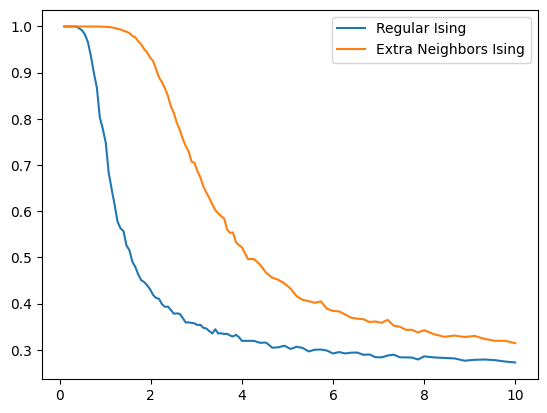

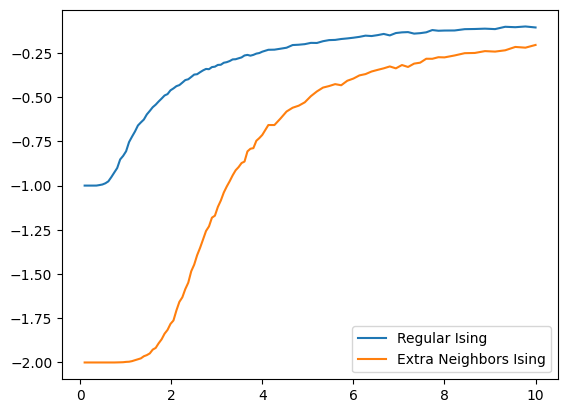

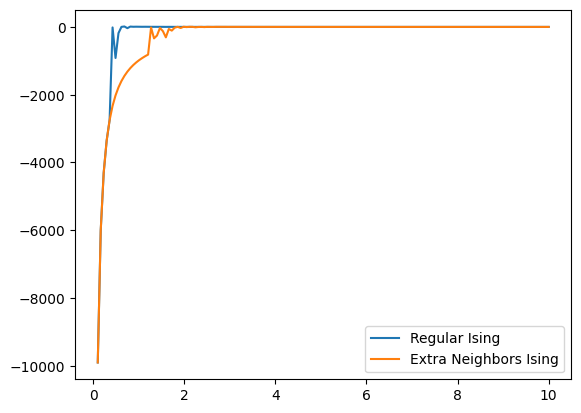

'\nplt.plot(T[:10], (F/T * ( np.mean(np.mean(ma_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(ma_list[0], axis= 1),axis=0)**2 ))[:10], label = "Regular Ising")\nplt.plot(T[:10], (F/T * ( np.mean(np.mean(mb_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(mb_list[0], axis= 1),axis=0)**2 ))[:10], label = "Extra Neighbors Ising")\nplt.legend()\nplt.show()\n'

In [11]:
plt.plot(T, np.mean(Sa_avg,axis=0), label = "Regular Ising")
plt.plot(T, np.mean(Sb_avg,axis=0), label = "Extra Neighbors Ising")
plt.legend()
plt.show()
plt.plot(T, np.mean(Ha_avg,axis=0)/F, label = "Regular Ising")
plt.plot(T, np.mean(Hb_avg,axis=0)/F, label = "Extra Neighbors Ising")
plt.legend()
plt.show()
plt.plot(T, np.mean(chia_list,axis=0), label = "Regular Ising")
plt.plot(T, np.mean(chib_list,axis=0), label = "Extra Neighbors Ising")
plt.legend()
plt.show()

'''
plt.plot(T[:10], (F/T * ( np.mean(np.mean(ma_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(ma_list[0], axis= 1),axis=0)**2 ))[:10], label = "Regular Ising")
plt.plot(T[:10], (F/T * ( np.mean(np.mean(mb_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(mb_list[0], axis= 1),axis=0)**2 ))[:10], label = "Extra Neighbors Ising")
plt.legend()
plt.show()
'''